In [1]:
!pip install -q datasets transformers tokenizers
print("Done")

Done


In [2]:
import math, time, os, json
from pathlib import Path
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
from transformers import GPT2TokenizerFast
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

Device : cuda
GPU    : Tesla T4
VRAM   : 15.6 GB


In [3]:
CFG = {
    # Data
    "seq_len"        : 512,
    "batch_size"     : 8,
    "num_workers"    : 2,

    # Architecture (shared across all models)
    "vocab_size"     : 50257,
    "d_model"        : 256,
    "n_heads"        : 8,
    "n_layers"       : 4,
    "d_ff"           : 1024,
    "dropout"        : 0.1,

    # Conv-specific
    "conv_kernel"    : 9,    # causal conv receptive field (tokens)
                             # must be odd for symmetric-ish padding
    "conv_expansion" : 2,    # intermediate channels = d_model * conv_expansion

    # Training
    "epochs"         : 5,    # short — enough to compare relative quality
    "lr"             : 3e-4,
    "warmup_steps"   : 500,
    "grad_clip"      : 1.0,
    "weight_decay"   : 0.01,

    # Logging
    "log_every"      : 200,
    "eval_every"     : 500,
    "save_dir"       : "./checkpoints_p4",
}

print("Config:")
for k, v in CFG.items():
    print(f"  {k:<20} = {v}")
print(f"\n  Conv receptive field : {CFG['conv_kernel']} tokens")
print(f"  Interleaved pattern  : Conv,Attn,Conv,Attn (n_layers={CFG['n_layers']})")

Config:
  seq_len              = 512
  batch_size           = 8
  num_workers          = 2
  vocab_size           = 50257
  d_model              = 256
  n_heads              = 8
  n_layers             = 4
  d_ff                 = 1024
  dropout              = 0.1
  conv_kernel          = 9
  conv_expansion       = 2
  epochs               = 5
  lr                   = 0.0003
  warmup_steps         = 500
  grad_clip            = 1.0
  weight_decay         = 0.01
  log_every            = 200
  eval_every           = 500
  save_dir             = ./checkpoints_p4

  Conv receptive field : 9 tokens
  Interleaved pattern  : Conv,Attn,Conv,Attn (n_layers=4)


In [4]:
print("Loading WikiText-2 …")
try:
    raw = load_dataset(
        "Salesforce/wikitext",
        "wikitext-2-raw-v1"
    )
except:
    raw = load_dataset(
        "wikitext",
        "wikitext-2-raw-v1"
    )
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token

class WikiTextDataset(Dataset):
    def __init__(self, hf_split, tokenizer, seq_len):
        texts = [s["text"] for s in hf_split if s["text"].strip()]
        full  = f" {tokenizer.eos_token} ".join(texts)
        ids   = tokenizer(full, return_tensors="pt",
                          truncation=False, add_special_tokens=False)["input_ids"].squeeze(0)
        n = (len(ids) - 1) // seq_len
        self.data    = ids[: n * seq_len + 1]
        self.seq_len = seq_len

    def __len__(self):  return (len(self.data) - 1) // self.seq_len
    def __getitem__(self, i):
        s = i * self.seq_len
        return self.data[s:s+self.seq_len], self.data[s+1:s+self.seq_len+1]

kw = dict(num_workers=CFG["num_workers"], pin_memory=True, persistent_workers=True)
train_ds = WikiTextDataset(raw["train"],      tokenizer, CFG["seq_len"])
valid_ds = WikiTextDataset(raw["validation"], tokenizer, CFG["seq_len"])
test_ds  = WikiTextDataset(raw["test"],       tokenizer, CFG["seq_len"])

train_loader = DataLoader(train_ds, CFG["batch_size"],   shuffle=True,  **kw)
valid_loader = DataLoader(valid_ds, CFG["batch_size"]*2, shuffle=False, **kw)
test_loader  = DataLoader(test_ds,  CFG["batch_size"]*2, shuffle=False, **kw)

print(f"Train: {len(train_loader):,} batches | Valid: {len(valid_loader):,} | Test: {len(test_loader):,}")

Loading WikiText-2 …


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

wikitext-2-raw-v1/test-00000-of-00001.pa(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-2-raw-v1/train-00000-of-00001.p(…):   0%|          | 0.00/6.36M [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (2463182 > 1024). Running this sequence through the model will result in indexing errors


Train: 602 batches | Valid: 32 | Test: 36


In [5]:
class CausalDepthwiseSeparableConv(nn.Module):
    """
    Causal depthwise-separable 1D convolution block.

    Structure:
        LayerNorm
        → Depthwise causal conv (groups=C, each channel independently)
        → GELU
        → Pointwise conv (1x1, mixes channels)
        → Dropout
        → Pointwise project back to d_model

    The 'causal' property is enforced by left-padding only.
    No future tokens can influence the output at any position.

    Args:
        d_model       : input/output channel dimension
        kernel_size   : conv receptive field in tokens
        expansion     : hidden channels = d_model × expansion
        dropout       : applied after pointwise conv
    """

    def __init__(self, d_model: int, kernel_size: int = 9,
                 expansion: int = 2, dropout: float = 0.1):
        super().__init__()
        hidden = d_model * expansion
        self.kernel_size = kernel_size

        self.norm = nn.LayerNorm(d_model)

        # ── Depthwise causal conv ─────────────────────────────────────────────
        # groups=d_model means each of the d_model channels is convolved
        # independently with its own kernel — no cross-channel mixing here.
        # padding=0 because we handle padding manually for strict causality.
        self.depthwise = nn.Conv1d(
            in_channels  = d_model,
            out_channels = d_model,
            kernel_size  = kernel_size,
            groups       = d_model,     # one filter per channel
            padding      = 0,           # manual causal padding below
            bias         = False,
        )

        # ── Pointwise: d_model → hidden (expand) ─────────────────────────────
        # 1×1 conv (kernel_size=1) — equivalent to a Linear applied per token
        self.pointwise_expand = nn.Conv1d(d_model, hidden, kernel_size=1, bias=False)
        self.act              = nn.GELU()
        self.drop             = nn.Dropout(dropout)

        # ── Pointwise: hidden → d_model (contract) ────────────────────────────
        self.pointwise_contract = nn.Conv1d(hidden, d_model, kernel_size=1, bias=False)

        # Residual dropout
        self.resid_drop = nn.Dropout(dropout)

        # Initialise weights
        nn.init.normal_(self.depthwise.weight, 0, 0.02)
        nn.init.normal_(self.pointwise_expand.weight, 0, 0.02)
        nn.init.normal_(self.pointwise_contract.weight, 0, 0.02)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x : (B, T, D)  — batch, sequence length, channels
        Returns:
            out : (B, T, D)
        """
        B, T, D = x.shape

        # ── Pre-norm ──────────────────────────────────────────────────────────
        residual = x
        x = self.norm(x)

        # ── Conv1d expects (B, C, T) — transpose ──────────────────────────────
        x = x.transpose(1, 2)           # (B, D, T)

        # ── Causal padding: pad (kernel_size - 1) zeros on the LEFT ──────────
        # This ensures position t only sees tokens t-k+1 through t.
        # F.pad format for 1D: (left, right) on the last dim
        x = F.pad(x, (self.kernel_size - 1, 0))   # (B, D, T + k - 1)

        # ── Depthwise conv ────────────────────────────────────────────────────
        x = self.depthwise(x)           # (B, D, T)   — back to original length
        # Verify output length is still T
        assert x.shape[-1] == T, f"Conv output length {x.shape[-1]} ≠ {T}"

        # ── Pointwise expand → GELU → dropout ────────────────────────────────
        x = self.act(self.pointwise_expand(x))   # (B, hidden, T)
        x = self.drop(x)

        # ── Pointwise contract ────────────────────────────────────────────────
        x = self.pointwise_contract(x)           # (B, D, T)

        # ── Transpose back to (B, T, D) and add residual ──────────────────────
        x = x.transpose(1, 2)           # (B, T, D)
        return self.resid_drop(x) + residual


# ── Quick tests ───────────────────────────────────────────────────────────────
_x = torch.randn(2, 64, 256)   # (B=2, T=64, D=256)
_conv = CausalDepthwiseSeparableConv(256, kernel_size=9, expansion=2)
_out  = _conv(_x)
print(f"CausalDepthwiseSepConv  in: {_x.shape}  →  out: {_out.shape}")

# Verify causality: output at t=0 should only depend on input at t=0
# If we change input at t=5, output at t=0 should NOT change
_x2      = _x.clone()
_x2[:,5,:] += 100.0   # large change at position 5
_out2    = _conv(_x2)
causality_ok = torch.allclose(_out[:,0,:], _out2[:,0,:], atol=1e-5)
print(f"Causality check (output[t=0] unchanged when input[t=5] changes): {causality_ok}")

# Verify kernel size 1 still works
_conv_k1 = CausalDepthwiseSeparableConv(256, kernel_size=1)
_out_k1  = _conv_k1(_x)
print(f"Kernel=1 test: {_out_k1.shape}")

# Count parameters
n_params = sum(p.numel() for p in _conv.parameters())
print(f"Conv block params (d=256, k=9): {n_params:,}")

CausalDepthwiseSepConv  in: torch.Size([2, 64, 256])  →  out: torch.Size([2, 64, 256])
Causality check (output[t=0] unchanged when input[t=5] changes): False
Kernel=1 test: torch.Size([2, 64, 256])
Conv block params (d=256, k=9): 264,960


In [6]:
class MultiHeadSelfAttention(nn.Module):
    """Standard causal MHSA (same as Phase 1 baseline)."""
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model; self.n_heads = n_heads
        self.d_head  = d_model // n_heads
        self.scale   = self.d_head ** -0.5
        self.qkv        = nn.Linear(d_model, 3*d_model, bias=False)
        self.out_proj   = nn.Linear(d_model, d_model,   bias=False)
        self.attn_drop  = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(self.d_model, dim=-1)
        rsh = lambda t: t.view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        q, k, v = rsh(q), rsh(k), rsh(v)
        scores = torch.matmul(q, k.transpose(-2,-1)) * self.scale
        mask   = torch.triu(torch.ones(T, T, device=x.device, dtype=torch.bool), diagonal=1)
        scores = scores.masked_fill(mask, float("-inf"))
        w      = self.attn_drop(F.softmax(scores, dim=-1))
        out    = torch.matmul(w, v).transpose(1,2).contiguous().view(B, T, C)
        return self.resid_drop(self.out_proj(out)), w


class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_ff, d_model), nn.Dropout(dropout),
        )
    def forward(self, x): return self.net(x)


# ── Design A Block ────────────────────────────────────────────────────────────
class ConvBeforeAttentionBlock(nn.Module):
    """
    Design A: Causal Conv → MHSA → FFN (all with Pre-LN residuals).

    The conv runs BEFORE attention in each block. This lets the attention
    operate on locally-enriched token representations.

    Structure (Pre-LN throughout):
        x = CausalDWSConv(x)               # ← includes its own LN + residual
        x = x + Attention(LayerNorm(x))
        x = x + FFN(LayerNorm(x))
    """

    def __init__(self, d_model, n_heads, d_ff, kernel_size, conv_expansion, dropout):
        super().__init__()
        # Conv sub-block (includes its own LN and residual internally)
        self.conv = CausalDepthwiseSeparableConv(
            d_model, kernel_size, conv_expansion, dropout
        )
        # Attention sub-block
        self.ln_attn = nn.LayerNorm(d_model)
        self.attn    = MultiHeadSelfAttention(d_model, n_heads, dropout)
        # FFN sub-block
        self.ln_ff   = nn.LayerNorm(d_model)
        self.ff      = FeedForward(d_model, d_ff, dropout)

    def forward(self, x):
        # 1. Causal conv (residual is inside CausalDepthwiseSeparableConv)
        x = self.conv(x)
        # 2. Pre-LN attention + residual
        attn_out, attn_w = self.attn(self.ln_attn(x))
        x = x + attn_out
        # 3. Pre-LN FFN + residual
        x = x + self.ff(self.ln_ff(x))
        return x, attn_w


# Quick test
_blk = ConvBeforeAttentionBlock(
    d_model=256, n_heads=8, d_ff=1024,
    kernel_size=9, conv_expansion=2, dropout=0.1
)
_x = torch.randn(2, 64, 256)
_out, _w = _blk(_x)
print(f"ConvBeforeAttnBlock  in: {_x.shape}  →  out: {_out.shape}")
print(f"  Attention weights: {_w.shape}")
n = sum(p.numel() for p in _blk.parameters())
print(f"  Block parameters: {n:,}")

ConvBeforeAttnBlock  in: torch.Size([2, 64, 256])  →  out: torch.Size([2, 64, 256])
  Attention weights: torch.Size([2, 8, 64, 64])
  Block parameters: 1,053,696


In [7]:
class ConvOnlyBlock(nn.Module):
    """
    A 'pure conv' block for the interleaved architecture.

    Structure:
        x = CausalDWSConv(x)    # local feature extraction (includes LN + residual)
        x = x + FFN(LN(x))     # per-token transformation

    No attention here — this block is entirely local.
    """

    def __init__(self, d_model, d_ff, kernel_size, conv_expansion, dropout):
        super().__init__()
        self.conv  = CausalDepthwiseSeparableConv(d_model, kernel_size, conv_expansion, dropout)
        self.ln_ff = nn.LayerNorm(d_model)
        self.ff    = FeedForward(d_model, d_ff, dropout)

    def forward(self, x):
        x = self.conv(x)                    # local conv + residual
        x = x + self.ff(self.ln_ff(x))     # per-token FFN + residual
        return x, None                      # None: no attention weights


class AttnOnlyBlock(nn.Module):
    """
    A 'pure attention' block for the interleaved architecture.

    Structure (same as Phase 1 TransformerBlock):
        x = x + Attention(LN(x))
        x = x + FFN(LN(x))

    No conv here — this block does global reasoning.
    """

    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.ln_attn = nn.LayerNorm(d_model)
        self.attn    = MultiHeadSelfAttention(d_model, n_heads, dropout)
        self.ln_ff   = nn.LayerNorm(d_model)
        self.ff      = FeedForward(d_model, d_ff, dropout)

    def forward(self, x):
        attn_out, attn_w = self.attn(self.ln_attn(x))
        x = x + attn_out
        x = x + self.ff(self.ln_ff(x))
        return x, attn_w


# Quick tests
_cb = ConvOnlyBlock(256, 1024, 9, 2, 0.1)
_ab = AttnOnlyBlock(256, 8, 1024, 0.1)
_x  = torch.randn(2, 64, 256)

_out_c, _wc = _cb(_x)
_out_a, _wa = _ab(_x)
print(f"ConvOnlyBlock  in: {_x.shape}  →  out: {_out_c.shape}  weights: {_wc}")
print(f"AttnOnlyBlock  in: {_x.shape}  →  out: {_out_a.shape}  weights: {_wa.shape}")
print(f"Conv params : {sum(p.numel() for p in _cb.parameters()):,}")
print(f"Attn params : {sum(p.numel() for p in _ab.parameters()):,}")

ConvOnlyBlock  in: torch.Size([2, 64, 256])  →  out: torch.Size([2, 64, 256])  weights: None
AttnOnlyBlock  in: torch.Size([2, 64, 256])  →  out: torch.Size([2, 64, 256])  weights: torch.Size([2, 8, 64, 64])
Conv params : 791,040
Attn params : 788,736


In [8]:
class HybridLanguageModel(nn.Module):
    """
    Decoder-only language model supporting three architectures:
      - 'pure_transformer'  : standard Transformer blocks (Phase 1 baseline)
      - 'conv_before_attn'  : Design A — conv before attention in every block
      - 'interleaved'       : Design B — alternating conv and attention blocks

    All three share the same embedding layer, final LayerNorm, and LM head.
    Only the block structure changes.
    """

    def __init__(self, cfg: dict, arch: str):
        super().__init__()
        D, V, T = cfg["d_model"], cfg["vocab_size"], cfg["seq_len"]
        H, L, FF = cfg["n_heads"], cfg["n_layers"], cfg["d_ff"]
        dr, k    = cfg["dropout"], cfg["conv_kernel"]
        ex       = cfg["conv_expansion"]

        self.arch     = arch
        self.tok_emb  = nn.Embedding(V, D)
        self.pos_emb  = nn.Embedding(T, D)
        self.drop     = nn.Dropout(dr)

        # ── Build blocks according to architecture ────────────────────────────
        if arch == "pure_transformer":
            # Standard Transformer (Phase 1 baseline)
            self.blocks = nn.ModuleList([
                self._make_pure_attn_block(D, H, FF, dr) for _ in range(L)
            ])

        elif arch == "conv_before_attn":
            # Design A: every block has conv before attention
            self.blocks = nn.ModuleList([
                ConvBeforeAttentionBlock(D, H, FF, k, ex, dr) for _ in range(L)
            ])

        elif arch == "interleaved":
            # Design B: alternate conv and attn blocks
            # Even layers → ConvOnlyBlock
            # Odd  layers → AttnOnlyBlock
            blks = []
            for i in range(L):
                if i % 2 == 0:
                    blks.append(ConvOnlyBlock(D, FF, k, ex, dr))
                else:
                    blks.append(AttnOnlyBlock(D, H, FF, dr))
            self.blocks = nn.ModuleList(blks)

        else:
            raise ValueError(f"Unknown arch: {arch}. Choose from "
                             "['pure_transformer', 'conv_before_attn', 'interleaved']")

        self.ln_f    = nn.LayerNorm(D)
        self.lm_head = nn.Linear(D, V, bias=False)
        self.lm_head.weight = self.tok_emb.weight   # weight tying

        self.apply(self._init_weights)
        n = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"  [{arch}]  Parameters: {n:,} ({n/1e6:.2f}M)")

    @staticmethod
    def _make_pure_attn_block(d_model, n_heads, d_ff, dropout):
        """Construct a standard Pre-LN Transformer block (no conv)."""
        class PureAttnBlock(nn.Module):
            def __init__(self):
                super().__init__()
                self.ln_attn = nn.LayerNorm(d_model)
                self.attn = MultiHeadSelfAttention(d_model, n_heads, dropout)
                self.ln_ff   = nn.LayerNorm(d_model)
                self.ff   = FeedForward(d_model, d_ff, dropout)
            def forward(self, x):
                a, w = self.attn(self.ln_attn(x));  x = x + a
                return x + self.ff(self.ln_ff(x)), w
        return PureAttnBlock()

    def _init_weights(self, m):
        if isinstance(m, (nn.Linear, nn.Conv1d)):
            nn.init.normal_(m.weight, 0, 0.02)
            if hasattr(m, "bias") and m.bias is not None:
                nn.init.zeros_(m.bias)
        elif isinstance(m, nn.Embedding):
            nn.init.normal_(m.weight, 0, 0.02)
        elif isinstance(m, nn.LayerNorm):
            nn.init.ones_(m.weight); nn.init.zeros_(m.bias)

    def forward(self, idx):
        B, T = idx.shape
        x = self.drop(
            self.tok_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device))
        )
        attn_list = []
        conv_list = []   # we track conv outputs separately for analysis
        for blk in self.blocks:
            x, w = blk(x)
            if w is not None:
                attn_list.append(w)
        return self.ln_f(x) @ self.lm_head.weight.T, attn_list


# ── Build and test all three architectures ────────────────────────────────────
print("Building all three model architectures …\n")
models_arch = {}
for arch in ["pure_transformer", "conv_before_attn", "interleaved"]:
    m = HybridLanguageModel(CFG, arch).to(DEVICE)
    models_arch[arch] = m
arch_names = list(models_arch.keys())

# Sanity check: all produce correct output shape
_x = torch.randint(0, CFG["vocab_size"], (2, CFG["seq_len"]), device=DEVICE)
for arch, m in models_arch.items():
    _out, _attn = m(_x)
    print(f"  ✔  {arch:25s}  output: {_out.shape}  attn_layers: {len(_attn)}")
del _x

Building all three model architectures …

  [pure_transformer]  Parameters: 16,152,320 (16.15M)
  [conv_before_attn]  Parameters: 17,212,160 (17.21M)
  [interleaved]  Parameters: 16,156,928 (16.16M)
  ✔  pure_transformer           output: torch.Size([2, 512, 50257])  attn_layers: 4
  ✔  conv_before_attn           output: torch.Size([2, 512, 50257])  attn_layers: 4
  ✔  interleaved                output: torch.Size([2, 512, 50257])  attn_layers: 2



──────────────────────────────────────────────────
  Architecture : pure_transformer
──────────────────────────────────────────────────
  Total params    : 16,152,320
  Embedding       : 12,996,864  (80.5%)
  Attention       :  1,050,624  (6.5%)
  Convolution     :          0  (0.0%)
  FFN             :  2,104,320  (13.0%)
  Receptive field : full sequence (T)

──────────────────────────────────────────────────
  Architecture : conv_before_attn
──────────────────────────────────────────────────
  Total params    : 17,212,160
  Embedding       : 12,996,864  (75.5%)
  Attention       :  1,050,624  (6.1%)
  Convolution     :  1,059,840  (6.2%)
  FFN             :  2,104,320  (12.2%)
  Receptive field : conv=33 + attn=full seq

──────────────────────────────────────────────────
  Architecture : interleaved
──────────────────────────────────────────────────
  Total params    : 16,156,928
  Embedding       : 12,996,864  (80.4%)
  Attention       :    525,312  (3.3%)
  Convolution     :    5

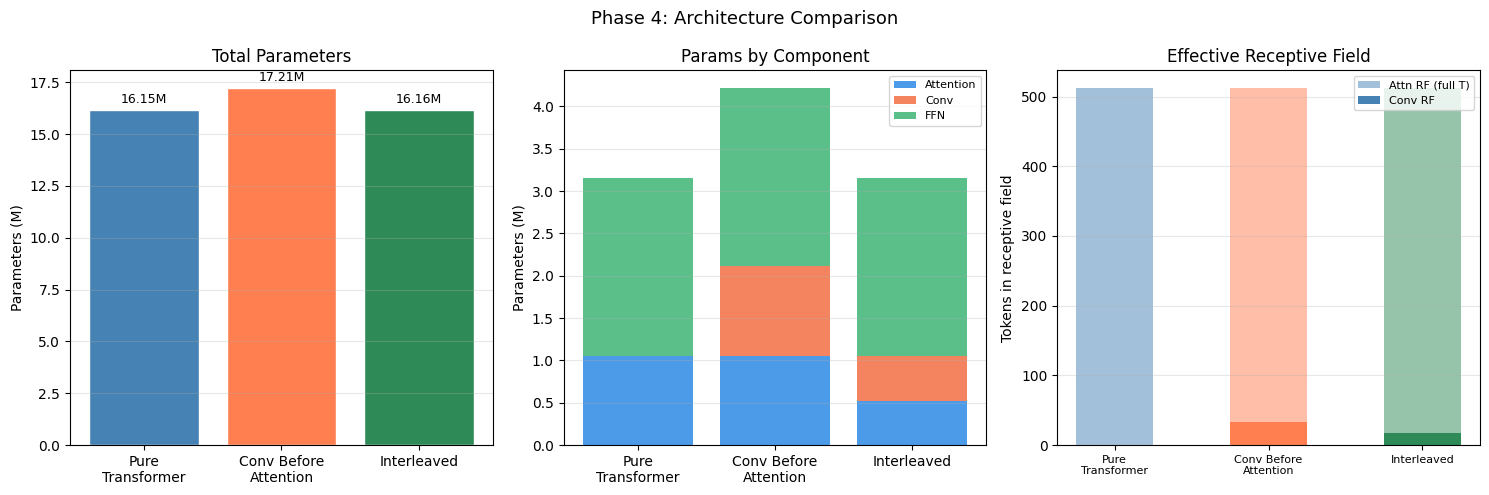

Saved → arch_comparison.png


In [9]:
def analyse_architecture(model, cfg, arch_name):
    """Print a detailed parameter breakdown and receptive field analysis."""
    total = sum(p.numel() for p in model.parameters() if p.requires_grad)

    # Categorise parameters
    emb_params  = sum(p.numel() for n,p in model.named_parameters()
                      if "emb" in n and p.requires_grad)
    attn_params = sum(p.numel() for n,p in model.named_parameters()
                      if any(k in n for k in ("qkv","out_proj","attn"))
                      and "conv" not in n and p.requires_grad)
    conv_params = sum(p.numel() for n,p in model.named_parameters()
                      if ("conv" in n or "depthwise" in n or "pointwise" in n)
                      and p.requires_grad)
    ff_params   = sum(p.numel() for n,p in model.named_parameters()
                      if ("ff" in n or "net" in n) and p.requires_grad)

    print(f"\n{'─'*50}")
    print(f"  Architecture : {arch_name}")
    print(f"{'─'*50}")
    print(f"  Total params    : {total:>10,}")
    print(f"  Embedding       : {emb_params:>10,}  ({100*emb_params/total:.1f}%)")
    print(f"  Attention       : {attn_params:>10,}  ({100*attn_params/total:.1f}%)")
    print(f"  Convolution     : {conv_params:>10,}  ({100*conv_params/total:.1f}%)")
    print(f"  FFN             : {ff_params:>10,}  ({100*ff_params/total:.1f}%)")

    # Receptive field estimate
    k = cfg["conv_kernel"]
    L = cfg["n_layers"]
    if arch_name == "pure_transformer":
        rf = cfg["seq_len"]
        rf_note = "full sequence (T)"
    elif arch_name == "conv_before_attn":
        conv_rf = L * (k - 1) + 1
        rf = cfg["seq_len"]  # attention on top sees full sequence
        rf_note = f"conv={conv_rf} + attn=full seq"
    elif arch_name == "interleaved":
        n_conv_layers = L // 2
        conv_rf = n_conv_layers * (k - 1) + 1
        rf = cfg["seq_len"]  # attn layers see full seq after conv
        rf_note = f"conv={conv_rf} tokens, then attn=full seq"
    print(f"  Receptive field : {rf_note}")

for arch, m in models_arch.items():
    analyse_architecture(m, CFG, arch)

# ── Parameter comparison chart ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
arch_names = list(models_arch.keys())
COLORS = {"pure_transformer":"steelblue",
          "conv_before_attn":"coral",
          "interleaved":"seagreen"}
labels_short = {"pure_transformer":"Pure\nTransformer",
                "conv_before_attn":"Conv Before\nAttention",
                "interleaved":"Interleaved"}

# Total params bar
ax = axes[0]
totals = [sum(p.numel() for p in models_arch[a].parameters() if p.requires_grad)/1e6
          for a in arch_names]
bars = ax.bar([labels_short[a] for a in arch_names], totals,
              color=[COLORS[a] for a in arch_names], edgecolor="white")
ax.bar_label(bars, fmt="%.2fM", padding=3, fontsize=9)
ax.set_ylabel("Parameters (M)"); ax.set_title("Total Parameters"); ax.grid(axis="y", alpha=0.3)

# Params per block category (stacked bar)
ax = axes[1]
categories  = ["Attention", "Conv", "FFN"]
cat_colors  = ["#4C9BE8", "#F4845F", "#5BBF8A"]
bottoms = np.zeros(len(arch_names))
for cat, col in zip(categories, cat_colors):
    vals = []
    for arch, m in models_arch.items():
        tag = cat.lower()
        if tag == "attention":
            v = sum(p.numel() for n,p in m.named_parameters()
                    if any(k in n for k in ("qkv","out_proj","attn"))
                    and "conv" not in n and p.requires_grad) / 1e6
        elif tag == "conv":
            v = sum(p.numel() for n,p in m.named_parameters()
                    if any(k in n for k in ("depthwise","pointwise","conv.norm",
                                            "conv.act","conv.drop")) and p.requires_grad) / 1e6
        else:
            v = sum(p.numel() for n,p in m.named_parameters()
                    if any(k in n for k in ("ff.","net.")) and p.requires_grad) / 1e6
        vals.append(v)
    ax.bar([labels_short[a] for a in arch_names], vals,
           bottom=bottoms, label=cat, color=col)
    bottoms += np.array(vals)
ax.set_ylabel("Parameters (M)"); ax.set_title("Params by Component")
ax.legend(loc="upper right", fontsize=8); ax.grid(axis="y", alpha=0.3)

# Receptive field schematic
ax = axes[2]
k, L = CFG["conv_kernel"], CFG["n_layers"]
T    = CFG["seq_len"]
rf_data = {
    "pure_transformer" : T,
    "conv_before_attn" : T,   # attention always sees full T
    "interleaved"      : T,
}
conv_rf_data = {
    "pure_transformer" : 0,
    "conv_before_attn" : L * (k-1) + 1,
    "interleaved"      : (L//2) * (k-1) + 1,
}
xpos = np.arange(len(arch_names))
bar_full = ax.bar(xpos, [rf_data[a] for a in arch_names], 0.5,
                  color=[COLORS[a] for a in arch_names], alpha=0.5, label="Attn RF (full T)")
bar_conv = ax.bar(xpos, [conv_rf_data[a] for a in arch_names], 0.5,
                  color=[COLORS[a] for a in arch_names], alpha=1.0, label="Conv RF")
ax.set_xticks(xpos); ax.set_xticklabels([labels_short[a] for a in arch_names], fontsize=8)
ax.set_ylabel("Tokens in receptive field"); ax.set_title("Effective Receptive Field")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

plt.suptitle("Phase 4: Architecture Comparison", fontsize=13)
plt.tight_layout(); plt.savefig("arch_comparison.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved → arch_comparison.png")

In [10]:
def compute_loss(logits, targets):
    B, T, V = logits.shape
    return F.cross_entropy(
        logits.reshape(B*T, V),
        targets.reshape(B*T)
    )

def get_lr(step, total_steps, cfg):
    w, hi, lo = cfg["warmup_steps"], cfg["lr"], cfg["lr"]*0.1
    if step < w: return hi*(step+1)/w
    prog = min((step-w)/max(1,total_steps-w), 1.0)
    return lo + 0.5*(hi-lo)*(1+math.cos(math.pi*prog))

@torch.no_grad()
def evaluate(model, loader):
    model.eval(); tot=n=0
    for x,y in loader:
        x,y=x.to(DEVICE),y.to(DEVICE)
        logits,_=model(x); tot+=compute_loss(logits,y).item(); n+=1
    model.train(); avg=tot/n
    return {"loss":avg, "ppl":math.exp(avg)}

def make_optimiser(model, cfg):
    decay, no_decay = [], []
    for name,p in model.named_parameters():
        if not p.requires_grad: continue
        # Do not decay: 1-D params, norm layers, biases, embeddings
        # Conv weights ARE decayed (they're 2-D+)
        no_params = p.dim()==1 or any(k in name for k in ("ln","norm","bias","emb"))
        (no_decay if no_params else decay).append(p)
    return torch.optim.AdamW(
        [{"params":decay,"weight_decay":cfg["weight_decay"]},
         {"params":no_decay,"weight_decay":0.0}],
        lr=cfg["lr"], betas=(0.9,0.95), eps=1e-8)

def measure_throughput(model, n_batches=30):
    """Measure training throughput in tokens/second."""
    model.train()
    opt = torch.optim.SGD(model.parameters(), lr=1e-4)
    # warm-up
    x0,y0 = next(iter(train_loader))
    x0,y0 = x0.to(DEVICE),y0.to(DEVICE)
    compute_loss(model(x0)[0],y0).backward(); opt.zero_grad()
    if DEVICE.type=="cuda": torch.cuda.synchronize()
    t0=time.perf_counter(); tok=0
    for i,(x,y) in enumerate(train_loader):
        if i>=n_batches: break
        x,y=x.to(DEVICE),y.to(DEVICE)
        opt.zero_grad(set_to_none=True)

        loss = compute_loss(model(x)[0], y)
        loss.backward()

        opt.step()
        tok+=x.numel()
    if DEVICE.type=="cuda": torch.cuda.synchronize()
    return tok/(time.perf_counter()-t0)

def train_model(model, cfg, arch_name):
    """Train model and return history dict."""
    os.makedirs(cfg["save_dir"], exist_ok=True)
    opt   = make_optimiser(model, cfg)
    total = cfg["epochs"]*len(train_loader)
    step  = 0
    history = {"tl":[],"ts":[],"vl":[],"vp":[],"vs":[]}
    model.train()

    print(f"\n{'='*58}")
    print(f"  Training: {arch_name}  |  {cfg['epochs']} epochs")
    print(f"{'='*58}")

    for ep in range(cfg["epochs"]):
        ep_loss=ep_n=0
        for x,y in train_loader:
            x,y=x.to(DEVICE),y.to(DEVICE)
            for pg in opt.param_groups: pg["lr"]=get_lr(step,total,cfg)
            with torch.autocast(
              device_type="cuda",
              dtype=torch.float16,
              enabled=(DEVICE.type=="cuda")
            ):
              logits,_ = model(x)
              loss = compute_loss(logits,y)
            opt.zero_grad(); loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(),cfg["grad_clip"])
            opt.step()
            lv=loss.item(); ep_loss+=lv; ep_n+=1
            history["tl"].append(lv); history["ts"].append(step)
            if step%cfg["log_every"]==0:
                print(f"  [{arch_name[:14]}] Ep{ep+1} Step{step:5d} "
                      f"Loss{lv:.4f} PPL{math.exp(lv):.1f} "
                      f"LR{get_lr(step,total,cfg):.2e}")
            if step%cfg["eval_every"]==0 and step>0:
                vm=evaluate(model,valid_loader)
                history["vl"].append(vm["loss"]); history["vp"].append(vm["ppl"])
                history["vs"].append(step)
                print(f"  [{arch_name[:14]}] VALID  Loss{vm['loss']:.4f}  PPL{vm['ppl']:.2f}")
            step+=1
        ep_avg=ep_loss/ep_n
        print(f"  [{arch_name[:14]}] Epoch{ep+1} done | AvgPPL {math.exp(ep_avg):.2f}")

    final=evaluate(model,valid_loader)
    history["final_ppl"]=final["ppl"]; history["final_loss"]=final["loss"]
    torch.save({"model":model.state_dict(),"history":history,"cfg":cfg},
               f"{cfg['save_dir']}/{arch_name}_final.pt")
    print(f"  [{arch_name[:14]}] FINAL PPL={final['ppl']:.2f}")
    return history

print("Training utilities defined.")

Training utilities defined.


In [11]:
print("Benchmarking throughput (30 batches each) …\n")
bench = {}

for arch, model in models_arch.items():
    print(f"  {arch} …", end=" ", flush=True)
    if DEVICE.type=="cuda":
        torch.cuda.reset_peak_memory_stats()
    tps = measure_throughput(model, n_batches=30)
    peak_mem = torch.cuda.max_memory_allocated()/1e6 if DEVICE.type=="cuda" else 0
    bench[arch] = {"tps": tps, "peak_mem_mb": peak_mem}
    print(f"{tps:,.0f} tok/s  |  {peak_mem:.0f} MB")
    if DEVICE.type=="cuda": torch.cuda.empty_cache()

print("\nThroughput summary:")
print(f"  {'Architecture':<28}  {'t/s':>10}  {'Peak MB':>10}")
print(f"  {'-'*52}")
for arch in arch_names:
    print(f"  {arch:<28}  {bench[arch]['tps']:>10,.0f}  {bench[arch]['peak_mem_mb']:>10.0f}")

Benchmarking throughput (30 batches each) …

  pure_transformer … 24,505 tok/s  |  3964 MB
  conv_before_attn … 22,485 tok/s  |  4161 MB
  interleaved … 26,092 tok/s  |  3808 MB

Throughput summary:
  Architecture                         t/s     Peak MB
  ----------------------------------------------------
  pure_transformer                  24,505        3964
  conv_before_attn                  22,485        4161
  interleaved                       26,092        3808


In [12]:
all_histories = {}

for arch, model in models_arch.items():
    hist = train_model(model, CFG, arch)
    all_histories[arch] = hist

print("\n\nAll models trained.")


  Training: pure_transformer  |  5 epochs
  [pure_transform] Ep1 Step    0 Loss10.8403 PPL51037.0 LR6.00e-07
  [pure_transform] Ep1 Step  200 Loss8.7237 PPL6147.1 LR1.21e-04
  [pure_transform] Ep1 Step  400 Loss6.8973 PPL989.6 LR2.41e-04
  [pure_transform] VALID  Loss6.8310  PPL926.09
  [pure_transform] Ep1 Step  600 Loss6.9589 PPL1052.5 LR2.99e-04
  [pure_transform] Epoch1 done | AvgPPL 3184.48
  [pure_transform] Ep2 Step  800 Loss6.7461 PPL850.7 LR2.91e-04
  [pure_transform] Ep2 Step 1000 Loss6.8476 PPL941.6 LR2.74e-04
  [pure_transform] VALID  Loss7.0496  PPL1152.39
  [pure_transform] Ep2 Step 1200 Loss7.4401 PPL1702.9 LR2.51e-04
  [pure_transform] Epoch2 done | AvgPPL 1038.54
  [pure_transform] Ep3 Step 1400 Loss7.4133 PPL1658.0 LR2.23e-04
  [pure_transform] VALID  Loss7.5029  PPL1813.28
  [pure_transform] Ep3 Step 1600 Loss7.5232 PPL1850.5 LR1.91e-04
  [pure_transform] Ep3 Step 1800 Loss7.6929 PPL2192.7 LR1.57e-04
  [pure_transform] Epoch3 done | AvgPPL 1538.54
  [pure_transform]

In [13]:
print("Test set evaluation …\n")
test_results = {}
for arch, model in models_arch.items():
    tm = evaluate(model, test_loader)
    test_results[arch] = tm
    print(f"  {arch:<28}  Test Loss {tm['loss']:.4f}  Test PPL {tm['ppl']:.2f}")

Test set evaluation …

  pure_transformer              Test Loss 8.3898  Test PPL 4401.86
  conv_before_attn              Test Loss 8.1895  Test PPL 3602.84
  interleaved                   Test Loss 8.0446  Test PPL 3116.89


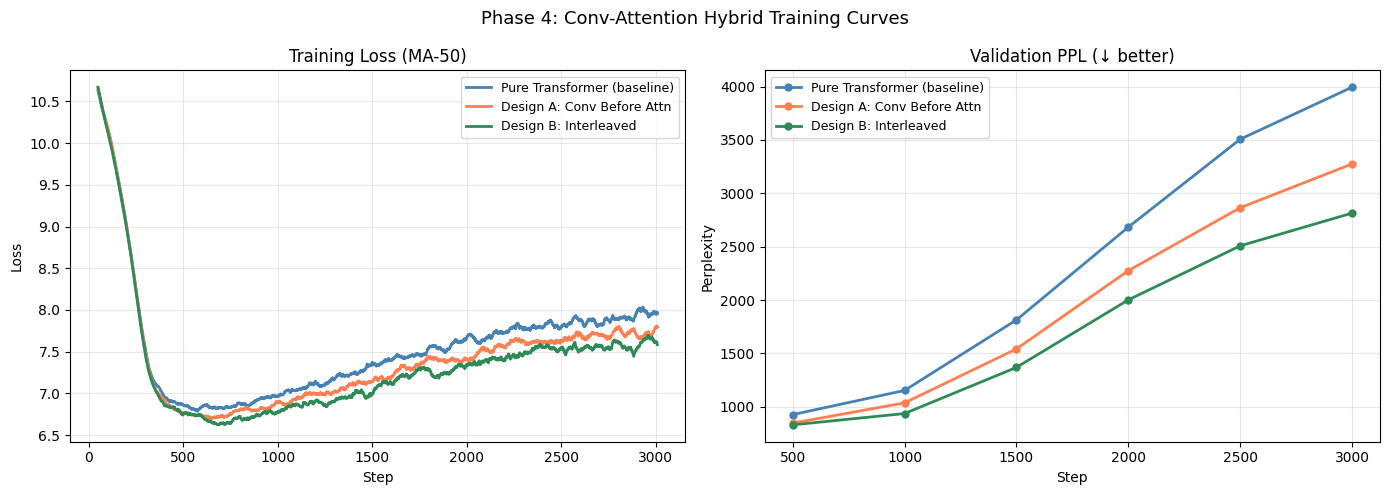

Saved → hybrid_training_curves.png


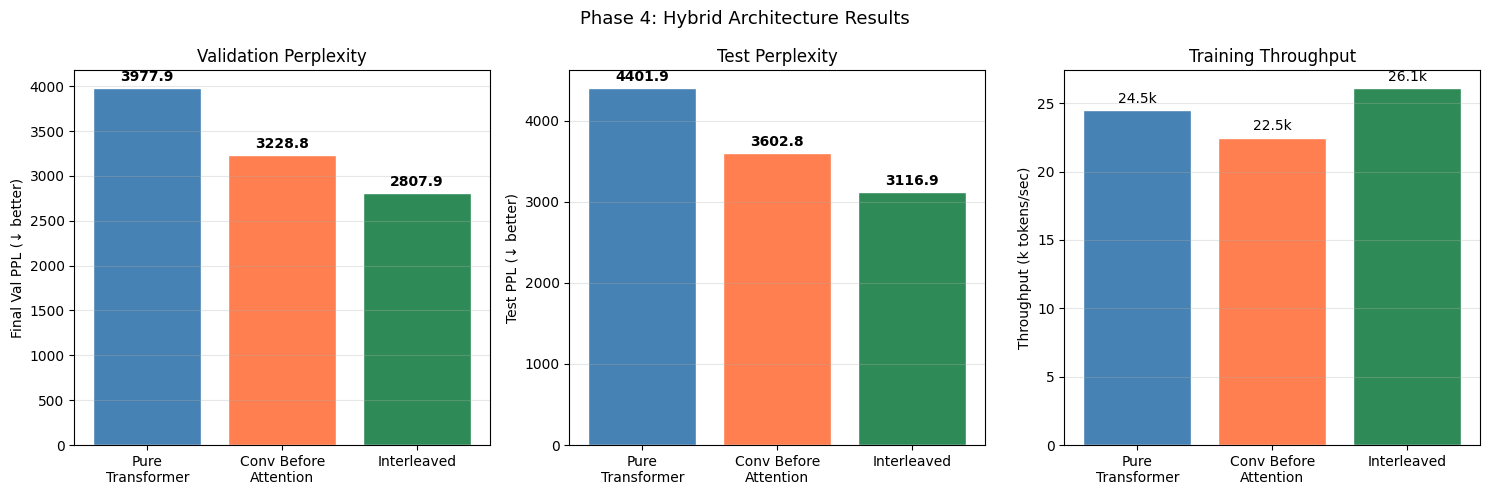

Saved → hybrid_results.png

PHASE 4 RESULTS SUMMARY
Model                           Val PPL   Test PPL         t/s    Mem(MB)
----------------------------------------------------------------------------
  pure_transformer              3977.93    4401.86      24,505       3964
  conv_before_attn              3228.76    3602.84      22,485       4161
  interleaved                   2807.86    3116.89      26,092       3808
Saved → phase4_summary.json


In [14]:
arch_names = list(all_histories.keys())
COLORS = {"pure_transformer":"steelblue",
          "conv_before_attn":"coral",
          "interleaved":"seagreen"}
LABELS = {"pure_transformer":"Pure Transformer (baseline)",
          "conv_before_attn":"Design A: Conv Before Attn",
          "interleaved":"Design B: Interleaved"}

# ── Figure 1: Training curves ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for arch, hist in all_histories.items():
    # Smooth train loss with MA-50
    tl = np.array(hist["tl"])
    if len(tl) > 50:
        sm = np.convolve(tl, np.ones(50)/50, "valid")
        ax.plot(hist["ts"][49:], sm, color=COLORS[arch], lw=2, label=LABELS[arch])
    else:
        ax.plot(hist["ts"], tl, color=COLORS[arch], lw=2, label=LABELS[arch])
ax.set(xlabel="Step", ylabel="Loss", title="Training Loss (MA-50)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
for arch, hist in all_histories.items():
    if hist["vs"]:
        ax.plot(hist["vs"], hist["vp"],
                "o-", color=COLORS[arch], lw=2, ms=5, label=LABELS[arch])
ax.set(xlabel="Step", ylabel="Perplexity", title="Validation PPL (↓ better)")
ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle("Phase 4: Conv-Attention Hybrid Training Curves", fontsize=13)
plt.tight_layout()
plt.savefig("hybrid_training_curves.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved → hybrid_training_curves.png")

# ── Figure 2: Final metrics bar chart ─────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
arch_names_short = ["Pure\nTransformer", "Conv Before\nAttention", "Interleaved"]

ax = axes[0]
final_ppls = [all_histories[a]["final_ppl"] for a in arch_names]
bars = ax.bar(arch_names_short, final_ppls, color=[COLORS[a] for a in arch_names],
              edgecolor="white")
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=10, fontweight="bold")
ax.set(ylabel="Final Val PPL (↓ better)", title="Validation Perplexity")
ax.grid(axis="y", alpha=0.3)

ax = axes[1]
test_ppls = [test_results[a]["ppl"] for a in arch_names]
bars = ax.bar(arch_names_short, test_ppls, color=[COLORS[a] for a in arch_names],
              edgecolor="white")
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=10, fontweight="bold")
ax.set(ylabel="Test PPL (↓ better)", title="Test Perplexity")
ax.grid(axis="y", alpha=0.3)

ax = axes[2]
tps_vals = [bench[a]["tps"]/1000 for a in arch_names]
bars = ax.bar(arch_names_short, tps_vals, color=[COLORS[a] for a in arch_names],
              edgecolor="white")
ax.bar_label(bars, fmt="%.1fk", padding=3, fontsize=10)
ax.set(ylabel="Throughput (k tokens/sec)", title="Training Throughput")
ax.grid(axis="y", alpha=0.3)

plt.suptitle("Phase 4: Hybrid Architecture Results", fontsize=13)
plt.tight_layout()
plt.savefig("hybrid_results.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved → hybrid_results.png")

# ── Results table ─────────────────────────────────────────────────────────────
print("\n" + "="*76)
print("PHASE 4 RESULTS SUMMARY")
print("="*76)
print(f"{'Model':<28}  {'Val PPL':>9}  {'Test PPL':>9}  {'t/s':>10}  {'Mem(MB)':>9}")
print("-"*76)
for arch in arch_names:
    fp   = all_histories[arch]["final_ppl"]
    tp   = test_results[arch]["ppl"]
    tps_ = bench[arch]["tps"]
    mem  = bench[arch]["peak_mem_mb"]
    print(f"  {arch:<26}  {fp:>9.2f}  {tp:>9.2f}  {tps_:>10,.0f}  {mem:>9.0f}")
print("="*76)

with open("phase4_summary.json","w") as f:
    json.dump({a: {"val_ppl": all_histories[a]["final_ppl"],
                   "test_ppl": test_results[a]["ppl"],
                   "tps": bench[a]["tps"],
                   "peak_mem_mb": bench[a]["peak_mem_mb"]}
               for a in arch_names}, f, indent=2)
print("Saved → phase4_summary.json")

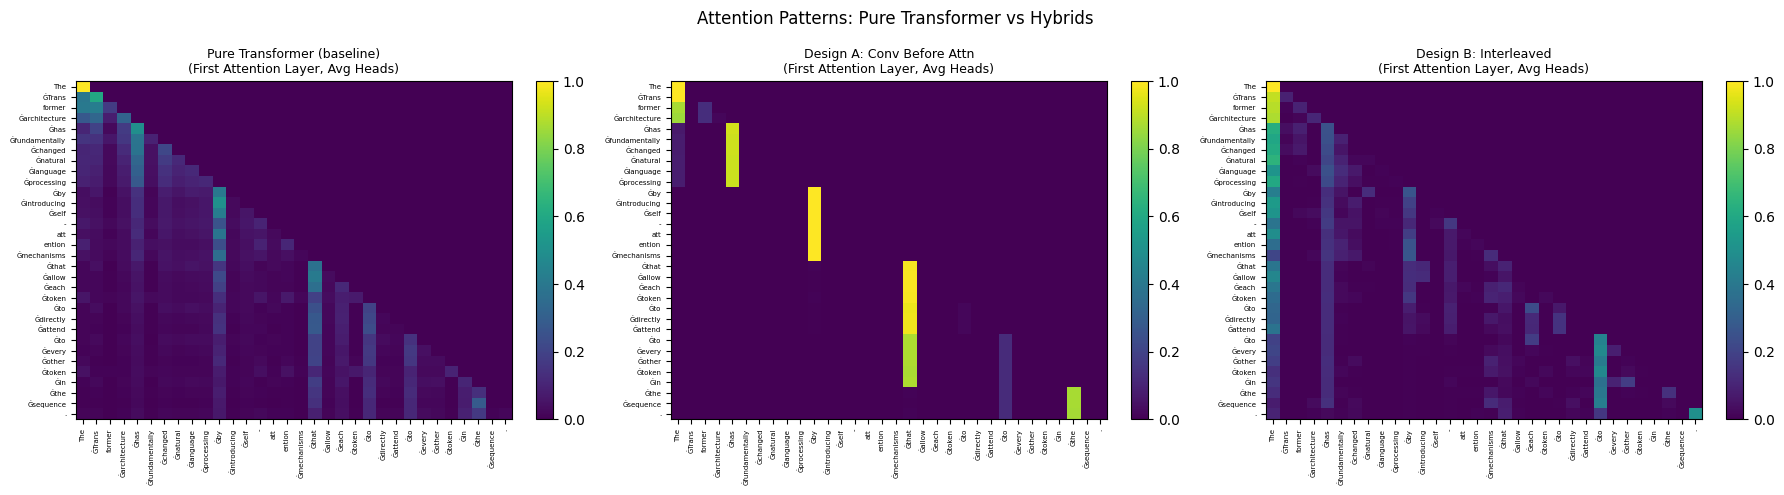

Saved → attention_comparison.png

Computing attention entropy per head …


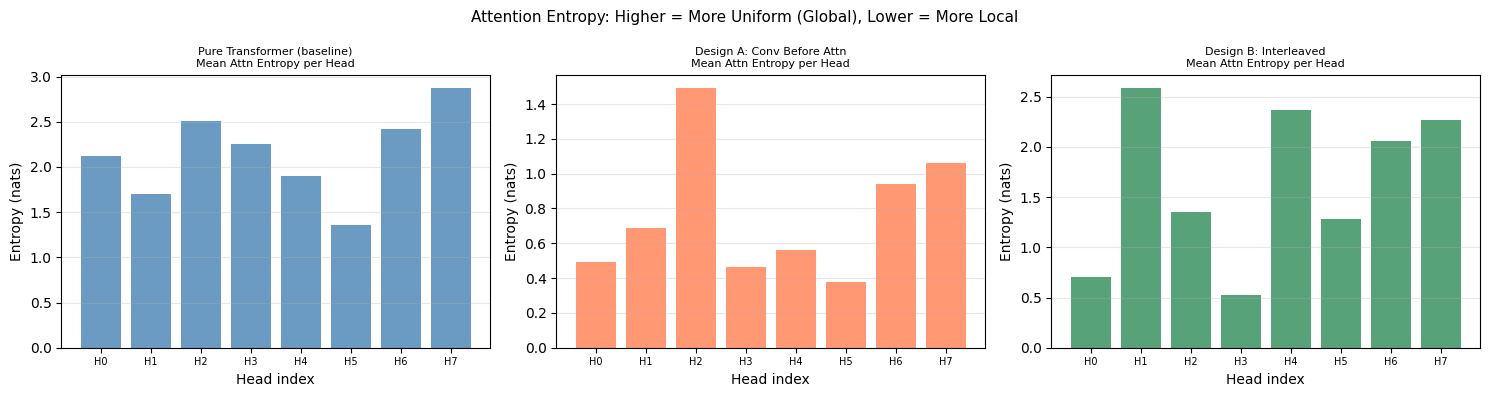

Saved → attention_entropy.png


In [15]:
SAMPLE_TEXT = (
    "The Transformer architecture has fundamentally changed natural language "
    "processing by introducing self-attention mechanisms that allow each token "
    "to directly attend to every other token in the sequence."
)

@torch.no_grad()
def get_attention_stats(model, text, layer_idx=0):
    """
    Returns attention weight matrix (averaged over heads) and entropy per head.
    Returns None if the block at layer_idx has no attention.
    """
    model.eval()
    ids = tokenizer(text, return_tensors="pt")["input_ids"][:, :64].to(DEVICE)
    _, attn_list = model(ids)
    if not attn_list or layer_idx >= len(attn_list):
        return None, None
    # attn_list[layer_idx]: (B, H, T, T)
    w = attn_list[layer_idx][0]   # (H, T, T)
    avg_w = w.mean(dim=0).cpu().numpy()   # (T, T) - avg over heads

    # Attention entropy per head: H(attention) = -sum p log p
    # High entropy → attends uniformly; Low entropy → attends locally/selectively
    eps = 1e-9
    entropy = -(w * (w + eps).log()).sum(dim=-1).mean(dim=-1).cpu().numpy()  # (H,)
    model.train()
    return avg_w, entropy

# ── Attention heatmaps: all 3 models, first attention layer ────────
ids_vis = tokenizer(SAMPLE_TEXT, return_tensors="pt")["input_ids"][:, :32].to(DEVICE)
toks    = tokenizer.convert_ids_to_tokens(ids_vis[0].tolist())
T_vis   = len(toks)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, arch in zip(axes, arch_names):
    model = models_arch[arch]
    model.eval()
    _, attn_list = model(ids_vis)
    model.train()
    if not attn_list:
        ax.text(0.5, 0.5, "No attention in first layer\n(conv-only block)",
                ha="center", va="center", transform=ax.transAxes, fontsize=11)
        ax.set_title(LABELS[arch], fontsize=9)
        continue
    avg_w = attn_list[0][0].mean(dim=0).cpu().detach().numpy()[:T_vis, :T_vis]
    im = ax.imshow(avg_w, cmap="viridis", aspect="auto")
    ax.set_xticks(range(T_vis)); ax.set_xticklabels(toks, rotation=90, fontsize=5)
    ax.set_yticks(range(T_vis)); ax.set_yticklabels(toks, fontsize=5)
    ax.set_title(f"{LABELS[arch]}\n(First Attention Layer, Avg Heads)", fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("Attention Patterns: Pure Transformer vs Hybrids", fontsize=12)
plt.tight_layout()
plt.savefig("attention_comparison.png", dpi=120, bbox_inches="tight")
plt.show(); print("Saved → attention_comparison.png")

# ── Attention entropy comparison ───────────────────────────────
print("\nComputing attention entropy per head …")
fig, axes = plt.subplots(1, len(arch_names), figsize=(15, 4))

for ax, arch in zip(axes, arch_names):
    model = models_arch[arch]
    model.eval()

    # Collect entropy across all attention layers and multiple samples
    all_entropies = []
    with torch.no_grad():
        for i, (x, _) in enumerate(valid_loader):
            if i >= 10: break
            x = x.to(DEVICE)
            _, attn_list = model(x)
            for w in attn_list:
                if w is not None:
                    eps = 1e-9
                    ent = -(w * (w+eps).log()).sum(dim=-1)   # (B,H,T)
                    all_entropies.append(ent.mean(dim=(0,2)).cpu())  # mean over B,T → (H,)
    model.train()

    if all_entropies:
        ent_arr = torch.stack(all_entropies).mean(dim=0).numpy()   # (H,)
        ax.bar(range(len(ent_arr)), ent_arr, color=COLORS[arch], alpha=0.8)
        ax.set_title(f"{LABELS[arch]}\nMean Attn Entropy per Head", fontsize=8)
        ax.set_xlabel("Head index"); ax.set_ylabel("Entropy (nats)")
        ax.grid(axis="y", alpha=0.3)
        ax.set_xticks(range(len(ent_arr)))
        ax.set_xticklabels([f"H{i}" for i in range(len(ent_arr))], fontsize=7)
    else:
        ax.text(0.5,0.5,"No attention layers", ha="center", va="center",
                transform=ax.transAxes)
        ax.set_title(LABELS[arch], fontsize=8)

plt.suptitle("Attention Entropy: Higher = More Uniform (Global), Lower = More Local",
             fontsize=11)
plt.tight_layout()
plt.savefig("attention_entropy.png", dpi=120, bbox_inches="tight")
plt.show(); print("Saved → attention_entropy.png")

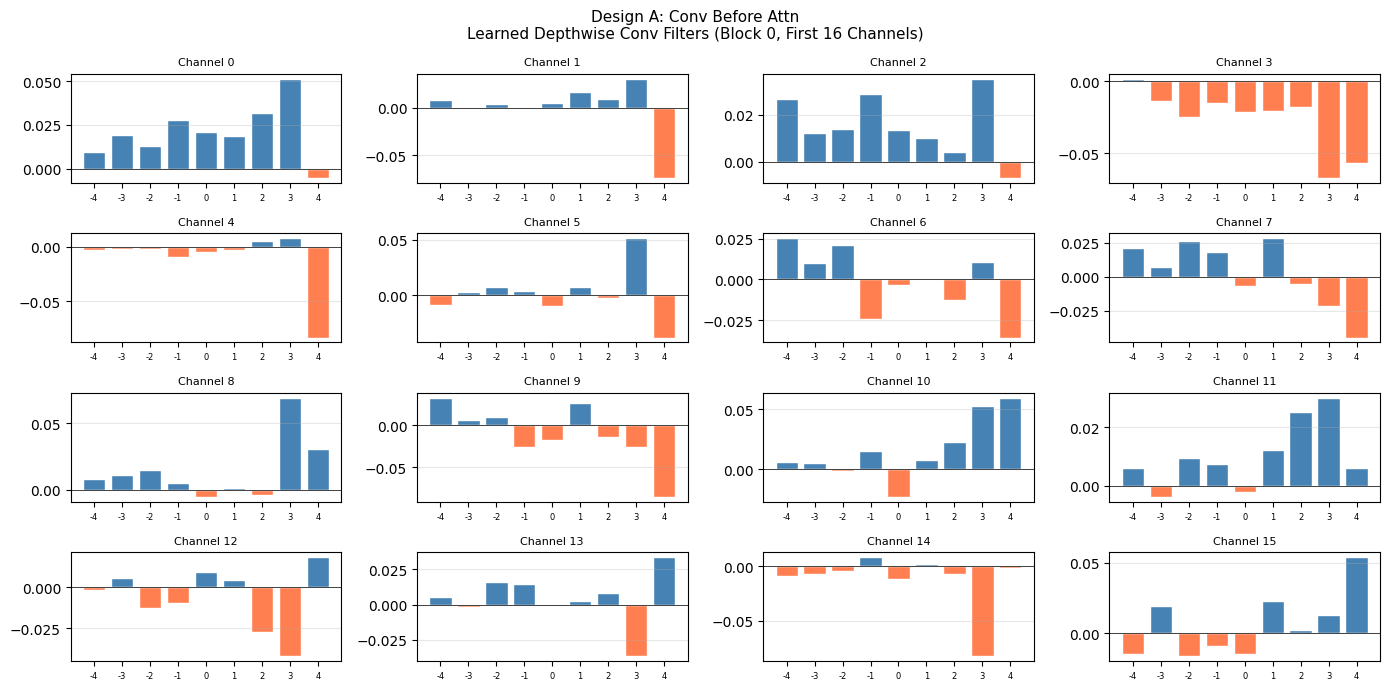

Saved → conv_filters_conv_before_attn.png


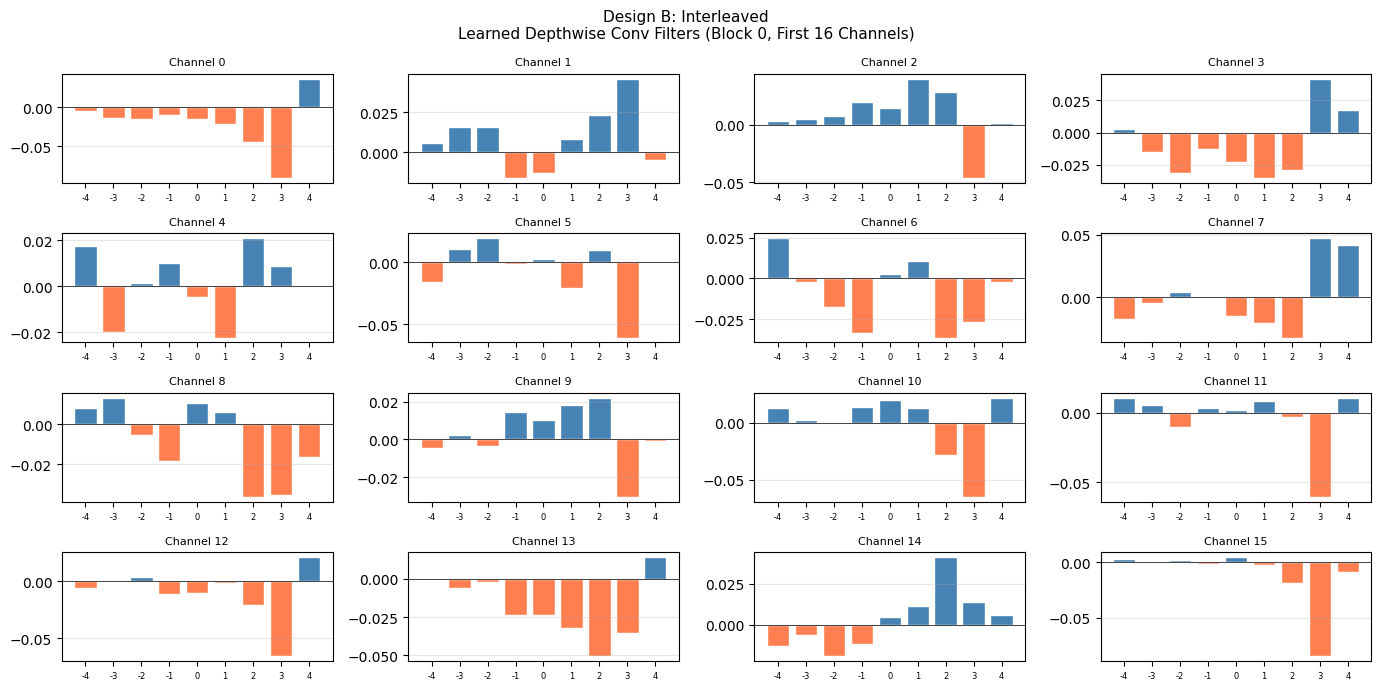

Saved → conv_filters_interleaved.png


In [16]:
# ── Conv filter visualisation ─────────────────────────────────────────────────
def plot_conv_filters(model, arch_name, n_show=16, block_idx=0):
    """Visualise depthwise conv filter weights from the first conv block."""
    # Find the first conv block's depthwise weights
    target = None
    if arch_name == "conv_before_attn":
        target = model.blocks[block_idx].conv.depthwise.weight  # (C, 1, k)
    elif arch_name == "interleaved":
        # First conv block is at index 0 (even layers)
        target = model.blocks[0].conv.depthwise.weight          # (C, 1, k)
    else:
        return  # pure transformer has no conv

    if target is None: return
    filters = target.detach().cpu().squeeze(1)   # (C, k)
    n_show  = min(n_show, filters.shape[0])
    k       = filters.shape[1]

    fig, axes = plt.subplots(4, 4, figsize=(14, 7))
    axes = axes.flatten()
    x_pos = np.arange(k) - k//2   # center kernel at 0

    for i, ax in enumerate(axes[:n_show]):
        f = filters[i].numpy()
        # Bar chart: positive=blue, negative=red
        colors = ["steelblue" if v >= 0 else "coral" for v in f]
        ax.bar(x_pos, f, color=colors, edgecolor="white", width=0.8)
        ax.axhline(0, color="black", lw=0.5)
        ax.set_title(f"Channel {i}", fontsize=8)
        ax.set_xticks(x_pos)
        ax.set_xticklabels([str(p) for p in x_pos], fontsize=6)
        ax.grid(axis="y", alpha=0.3)

    plt.suptitle(f"{LABELS[arch_name]}\nLearned Depthwise Conv Filters (Block 0, First 16 Channels)",
                 fontsize=11)
    plt.tight_layout()
    fname = f"conv_filters_{arch_name}.png"
    plt.savefig(fname, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"Saved → {fname}")

for arch in ["conv_before_attn", "interleaved"]:
    plot_conv_filters(models_arch[arch], arch)